In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

In [2]:
#%matplotlib inline
auto_plot_style()

In [3]:
def sipm_positions():
    size   = 6
    gap    = 0.2
    n      = 10
    offset = n * (size + gap) / 2.
    xy     = (np.arange(n) + 0.5) * (size + gap) - offset
    return (xy, *np.meshgrid(xy, xy, indexing="ij"))

def extent():
    size   = 6
    gap    = 0.2
    n      = 10
    offset = n * (size + gap) / 2.
    return (-offset, offset) * 2

def npmap(f, it):
    return np.array(list(map(f, it)))

def wire_pos():
    n = 12
    p =  5
    return np.arange(12) * p - (n - 1) * p/2

def wire_limits():
    p = wire_pos()
    return np.append(p - 2.5, p[-1] + 2.5)


empty_df = pd.DataFrame(dict(counts=0), index=pd.Index(np.arange(100), name="sensor_id"))
def image(df):
    df = df.set_index("sensor_id")
    df = pd.concat([df, empty_df])
    df = df.groupby(level=0).sum()
    return pd.DataFrame(dict(image=[df.sort_index().counts.values.reshape(1, 10,10)]))

def rotate(xy, a):
    c = np.cos(a)
    s = np.sin(a)
    m = np.array([ [c, -s]
                 , [s,  c] ])
    return m.dot(xy)
    
def gate_pos(df, a=np.pi/4):
    xrot, yrot = rotate(df.loc[:, list("xy")].values.T, np.pi/4)
    xi         = np.clip(np.digitize(xrot, wire_limits()) - 1, 0, 12)
    wx         = wire_pos()[xi]
    dx         = xrot - wx
    a          = np.arctan(dx/(df.z - (-5.20)))
    dx         = a/(np.pi/2) * 2.5
    x, y       = rotate(np.stack([wx+dx, yrot], axis=1).T, -np.pi/4)
    return pd.DataFrame(dict(event=df.event, x0=x, y0=y, z0=df.z))

def read_file(filename):
    sensor_hits = pd.read_hdf(filename, "/MC/sensor_hits").loc[lambda df: df.sensor_id < 100]
    sources     = pd.read_hdf(filename, "/MC/sources").drop(columns="e n".split())
    sources     = gate_pos(sources)
    sources     = sources.set_index("event")
    sources.insert(3, "r0", (sources.x0**2 + sources.y0**2)**0.5)
    sensor_hits = sensor_hits.groupby("event sensor_id".split()).count().rename(columns=dict(time="counts")).reset_index()
    images = (sensor_hits.groupby("event")
                         .apply(image, include_groups=False)
                         .reset_index(level=1, drop=True))
    out = pd.concat([sources, images], axis=1)
    out = out[~out.image.isna()]
    return out

def barycenter(df, sipm_x, sipm_y, nsipms):
    img = df.image.values[0][0]
    tot = img.sum().sum()
    xb  = (sipm_x * img).sum().sum() / tot
    yb  = (sipm_y * img).sum().sum() / tot
    return pd.Series(dict(x=xb, y=yb))

In [4]:
path      = Path("/home/gonzalo/data/COLINA/mc/colina_dsipms_2mm/")
filenames = sorted(path.glob("*.h5"))

In [5]:
testdf = read_file(filenames[0])
testdf

,x0,y0,z0,r0,image
event,,,,,
0,-15.999181,25.851183,-5.193165,30.401603,"[[[0, 0, 0, 1, 0, 0, 1, 4, 6, 1], [0, 0, 0, 0,..."
1,-10.691355,-30.049172,-5.172233,31.894479,"[[[1, 1, 4, 1, 0, 1, 0, 0, 0, 0], [1, 0, 4, 2,..."
2,-25.340307,5.862534,-5.159746,26.009623,"[[[0, 1, 1, 7, 13, 21, 12, 8, 10, 2], [0, 0, 4..."
3,-13.080611,21.247915,-5.190626,24.951478,"[[[0, 1, 0, 1, 0, 0, 1, 5, 4, 6], [0, 0, 1, 0,..."
4,-8.426368,8.499799,-5.162716,11.968720,"[[[0, 0, 0, 0, 0, 3, 4, 3, 0, 0], [0, 0, 0, 4,..."
...,...,...,...,...,...
49995,22.206332,-0.636028,-5.190965,22.215439,"[[[0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0,..."
49996,22.771996,-13.052474,-5.193925,26.247493,"[[[0, 0, 0, 1, 2, 0, 0, 0, 0, 0], [0, 0, 0, 1,..."
49997,15.107099,-19.983098,-5.195716,25.050921,"[[[0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 0, 1, 0,..."


In [6]:
rbins  = np.linspace(  0, 32, 81)
xybins = np.linspace(-32, 32, 81)
drbins = np.linspace(  0, 32, 81)

In [7]:
nsipms    = 10
sipm_pos  = sipm_positions()[0]
sipm_x    = sipm_positions()[1]
sipm_y    = sipm_positions()[2]
extents   = extent()
ticks     = np.arange(-30, 31, 10)

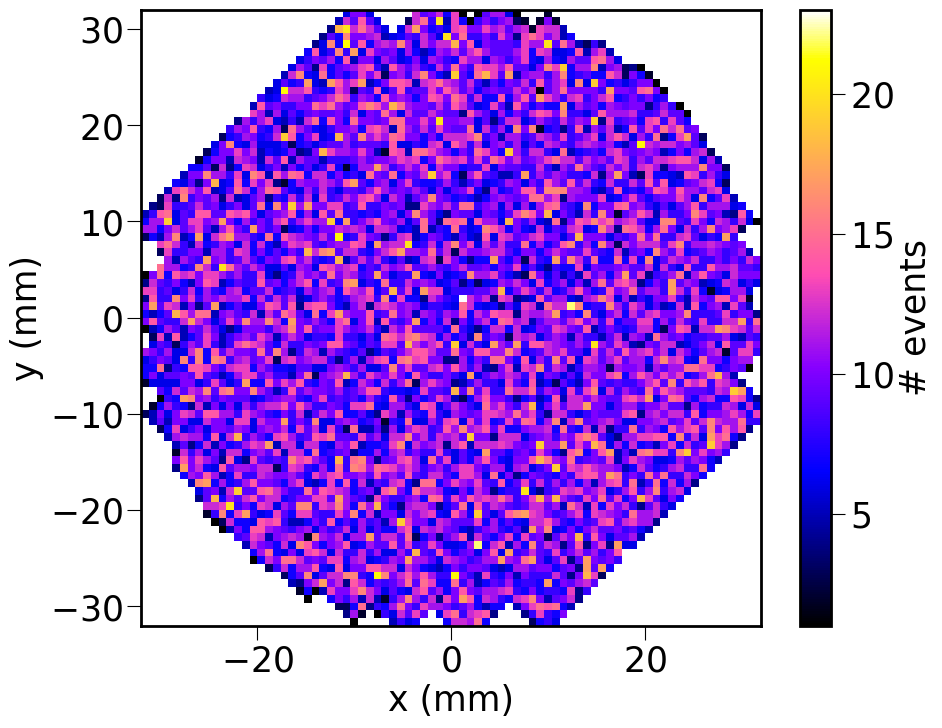

In [8]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

# Barycenter

In [9]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y, nsipms)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [10]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,-10.613194,17.459028,-15.999181,25.851183,-5.193165,30.401603,5.385987,-8.392156,9.971817
1,-7.039227,-18.308840,-10.691355,-30.049172,-5.172233,31.894479,3.652129,11.740332,12.295261
2,-17.134932,4.331507,-25.340307,5.862534,-5.159746,26.009623,8.205376,-1.531028,8.346990
3,-10.230000,16.557647,-13.080611,21.247915,-5.190626,24.951478,2.850611,-4.690267,5.488588
4,-7.595906,8.302924,-8.426368,8.499799,-5.162716,11.968720,0.830461,-0.196875,0.853479
...,...,...,...,...,...,...,...,...,...
49995,17.086532,1.200337,22.206332,-0.636028,-5.190965,22.215439,-5.119800,1.836365,5.439172
49996,18.462658,-11.536709,22.771996,-13.052474,-5.193925,26.247493,-4.309338,1.515765,4.568144
49997,12.262402,-14.755352,15.107099,-19.983098,-5.195716,25.050921,-2.844697,5.227746,5.951607


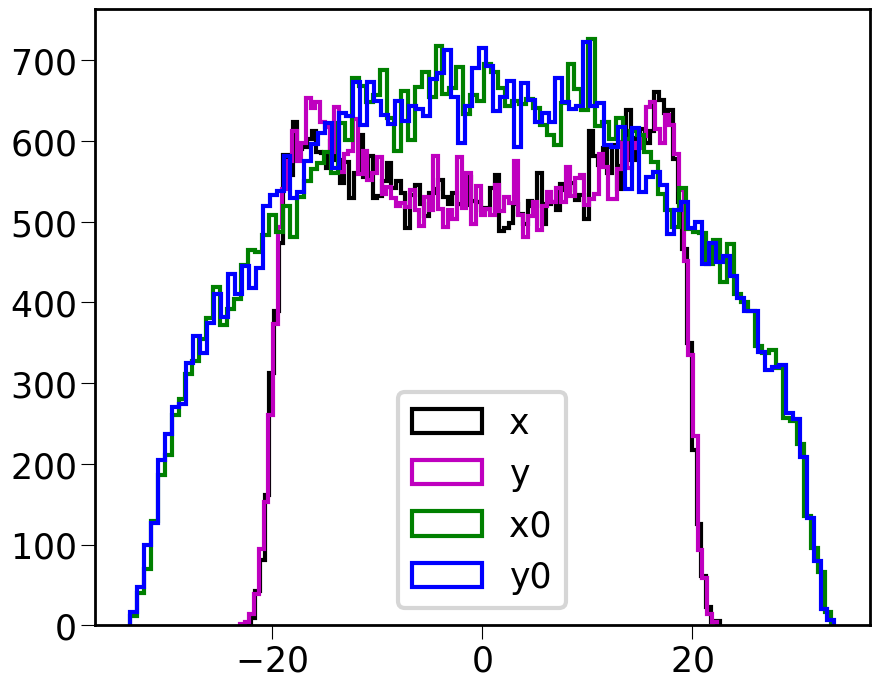

In [11]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

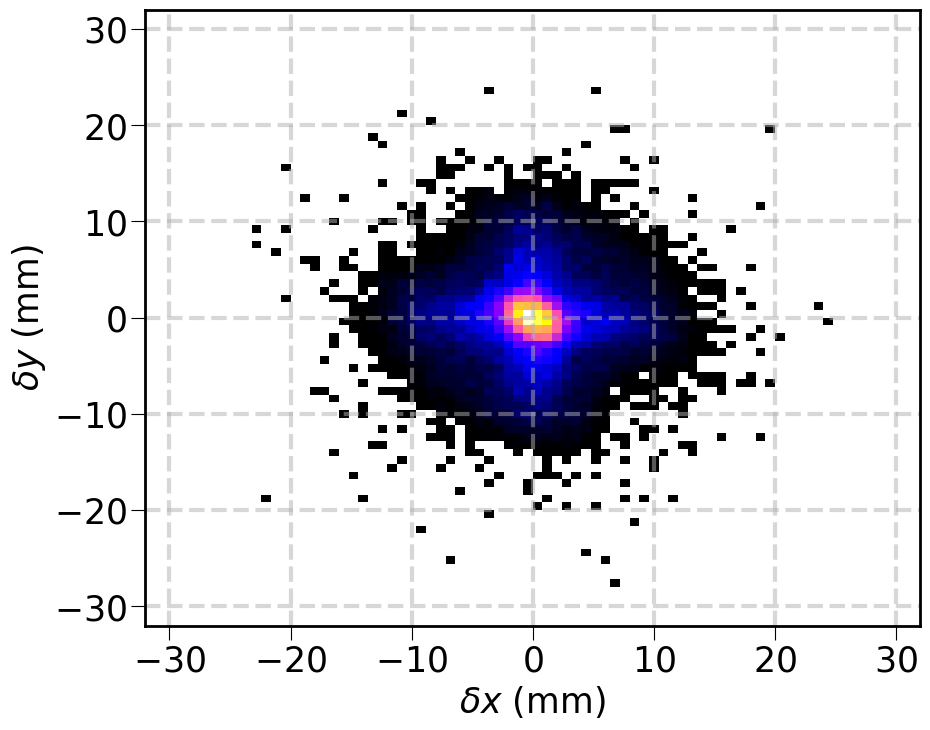

In [12]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

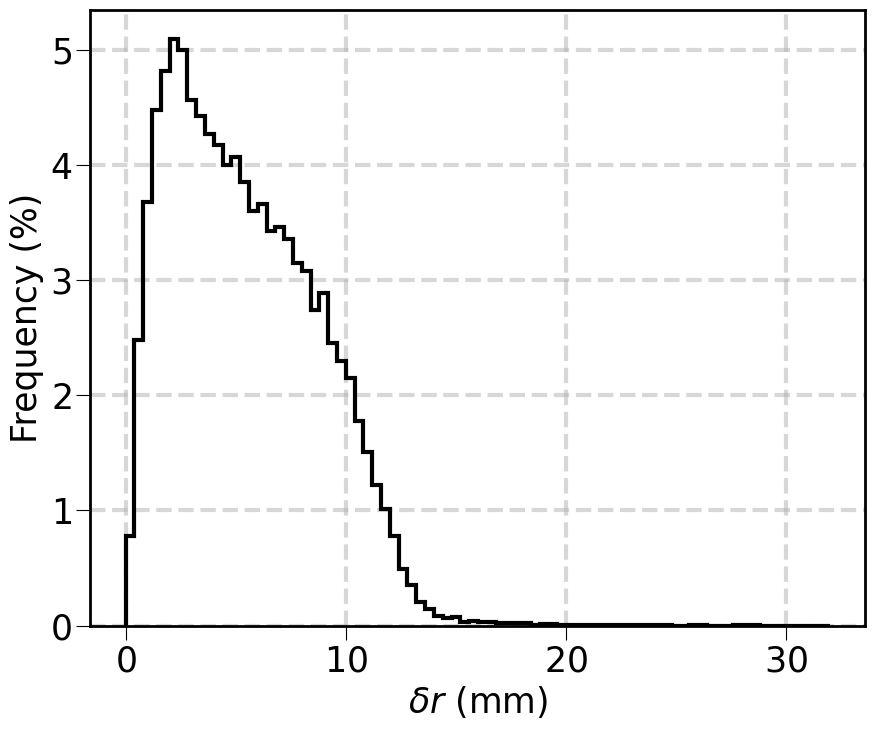

In [13]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

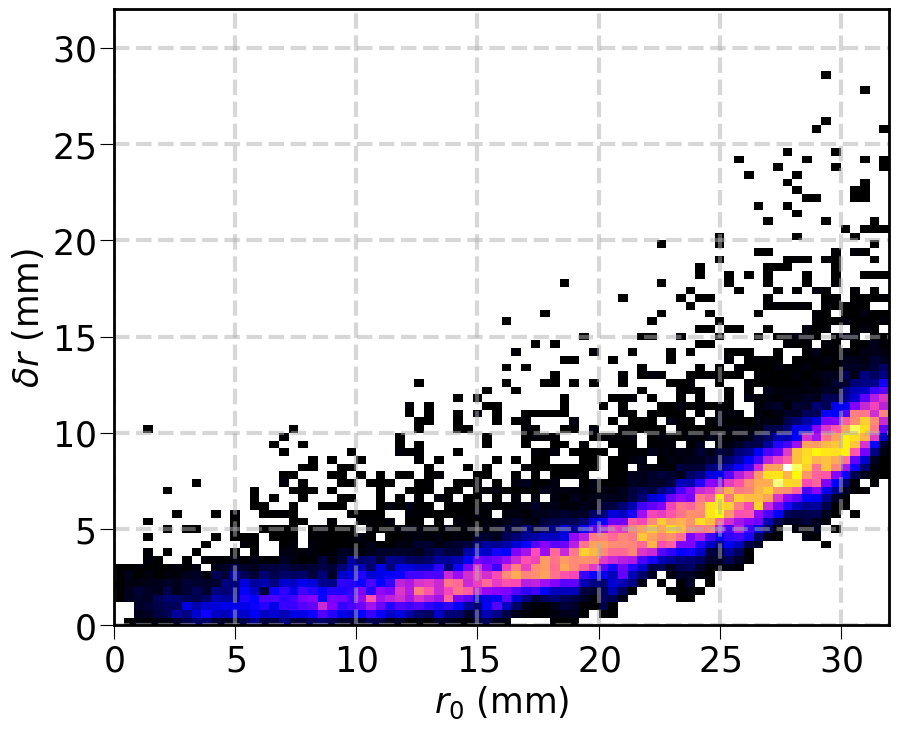

In [14]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

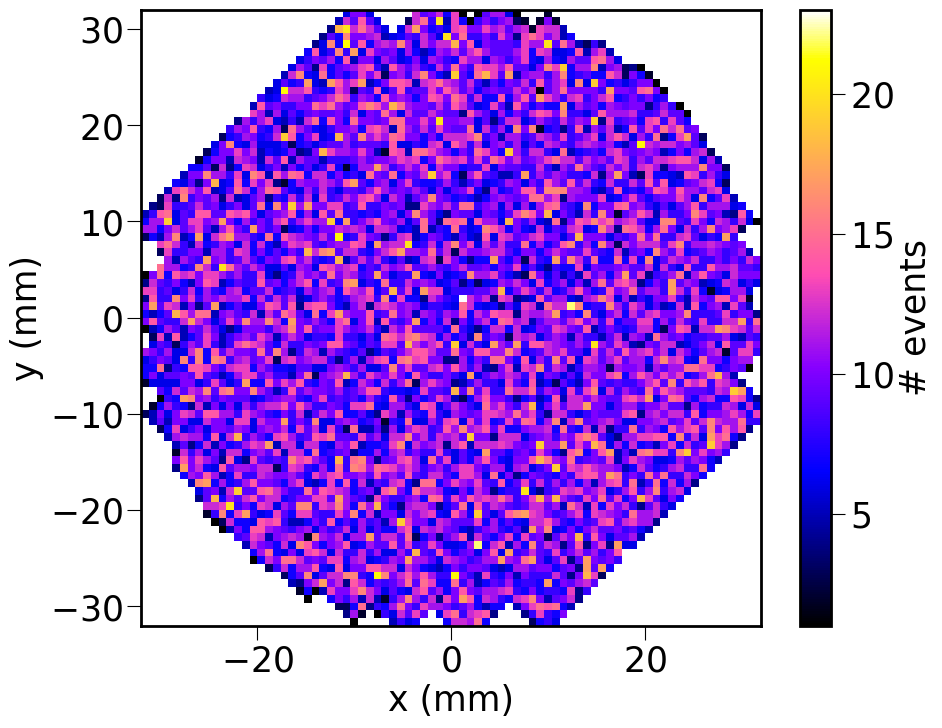

In [15]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

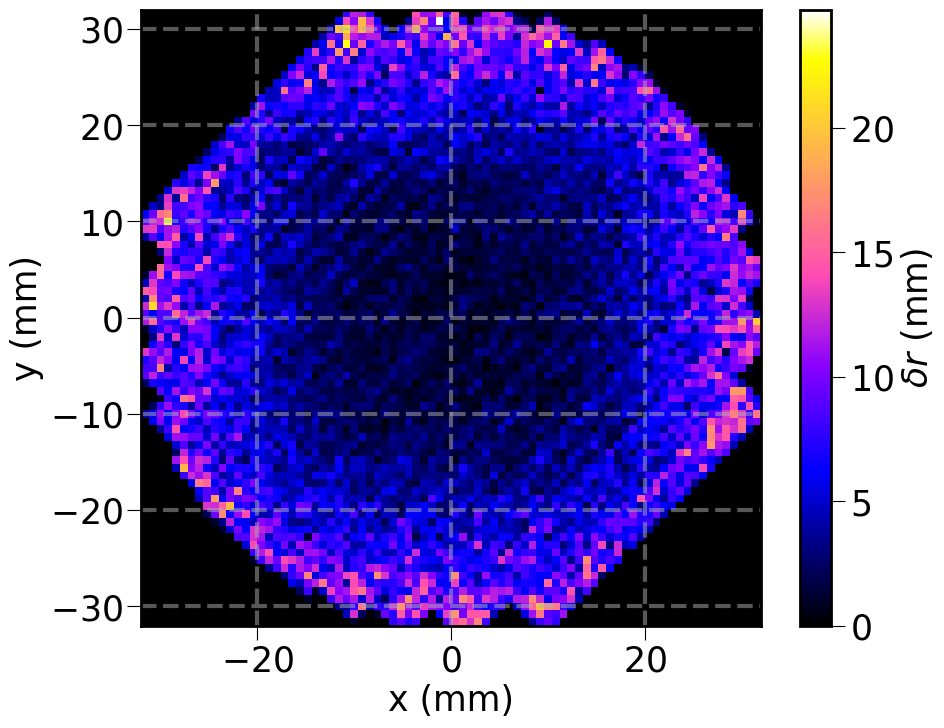

In [16]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

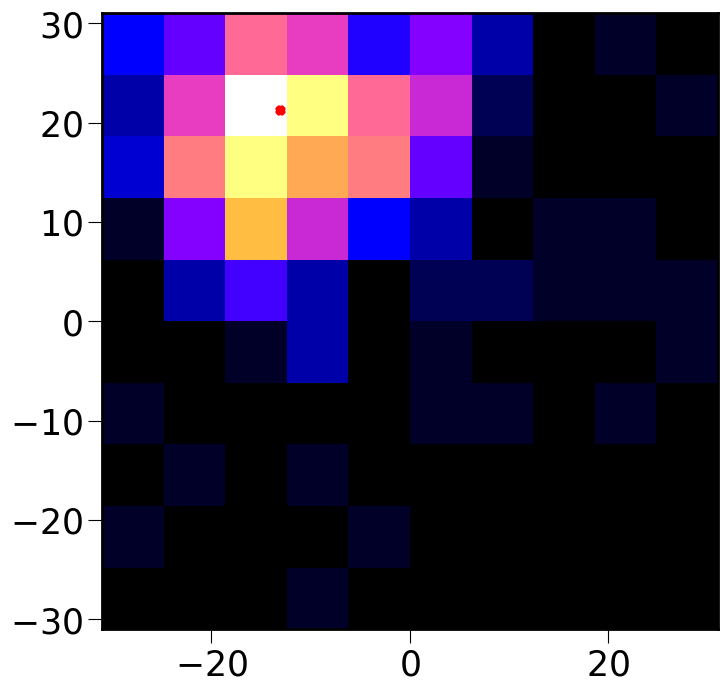

In [18]:
row = testdf.iloc[3]
img = row.image[0]
x   = row.x0
y   = row.y0
plt.imshow(img.T, origin="lower", extent=extent());
plt.scatter([x], [y], s=20, marker="X", color="r");

# NN

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

In [20]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [21]:
train     = pd.concat([read_file(filename) for filename in filenames[:5]])
test      = pd.concat([read_file(filename) for filename in filenames[5:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [22]:
model     = Linear(nsipms, nsipms)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
epochs = 50
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 50 of 50 | 10.86 s/item | ETA 0.2 min | Ellapsed 8.9 min


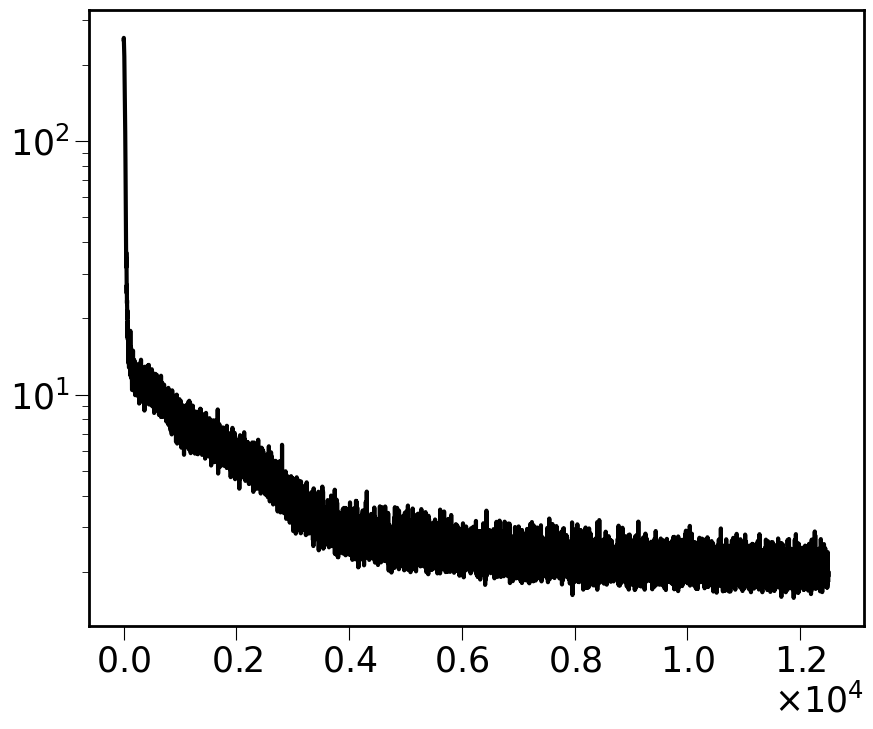

In [24]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [25]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

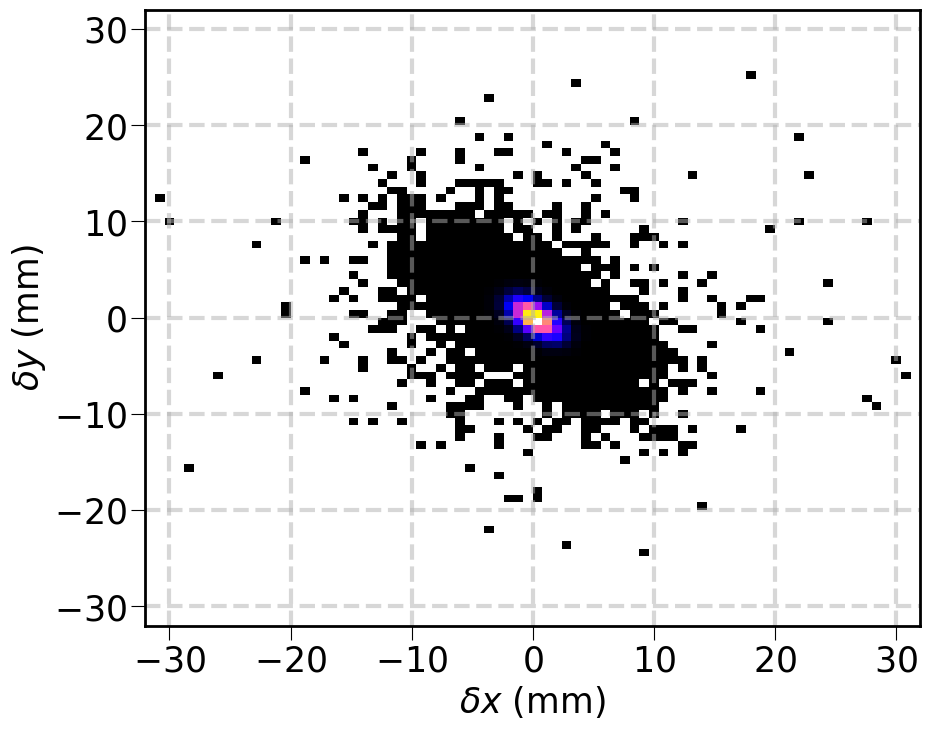

In [26]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

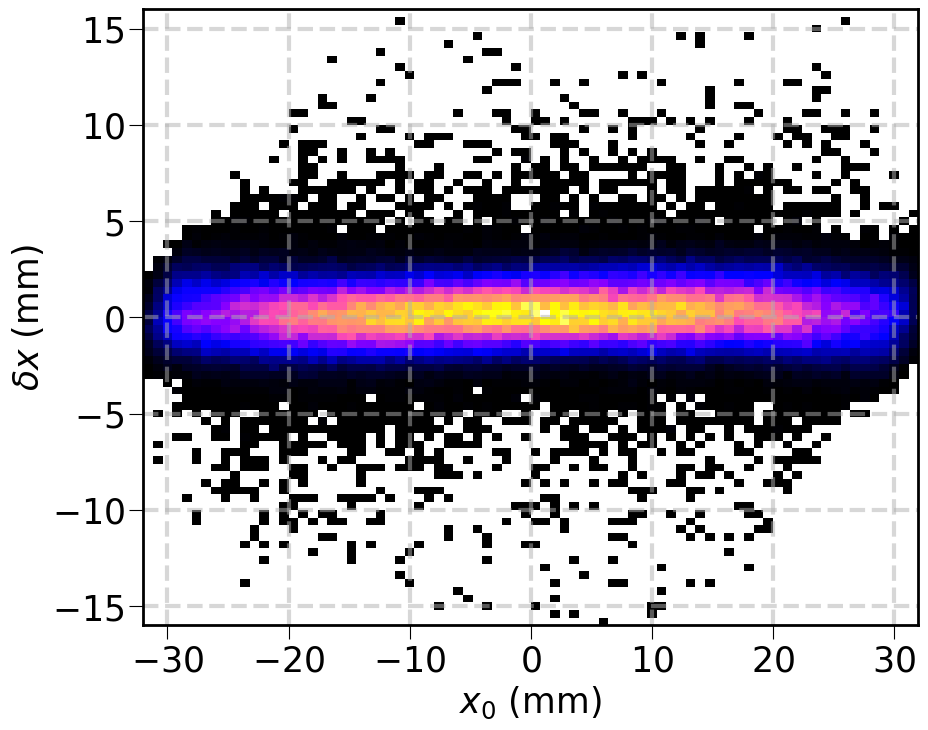

In [36]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins/2))
plt.xlabel("$x_0$ (mm)")
plt.ylabel("$\delta x$ (mm)")
plt.grid()

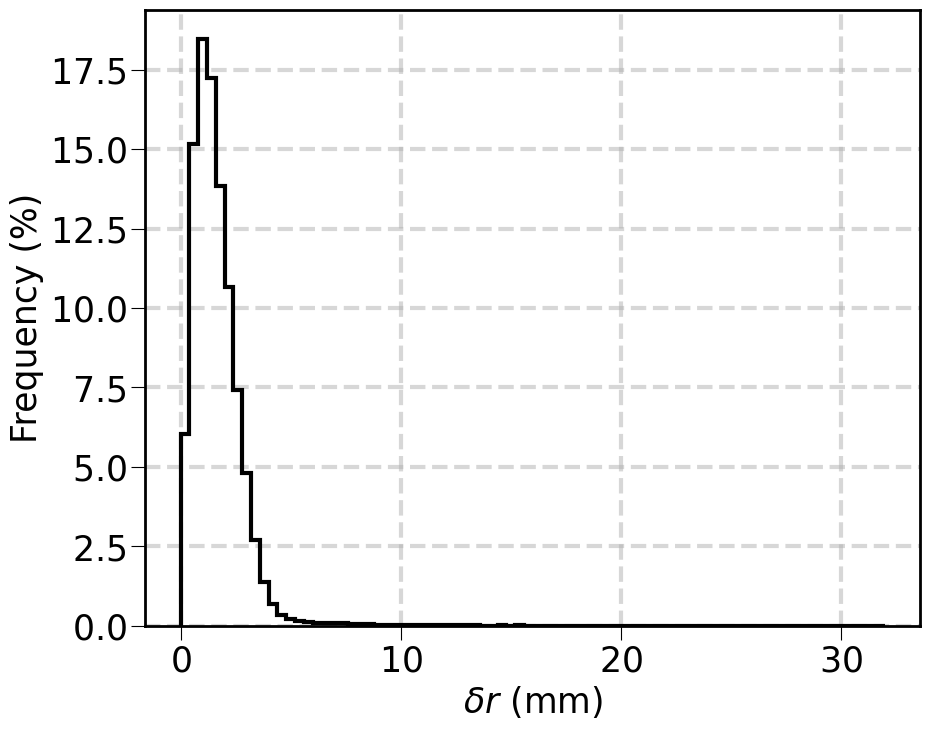

In [37]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

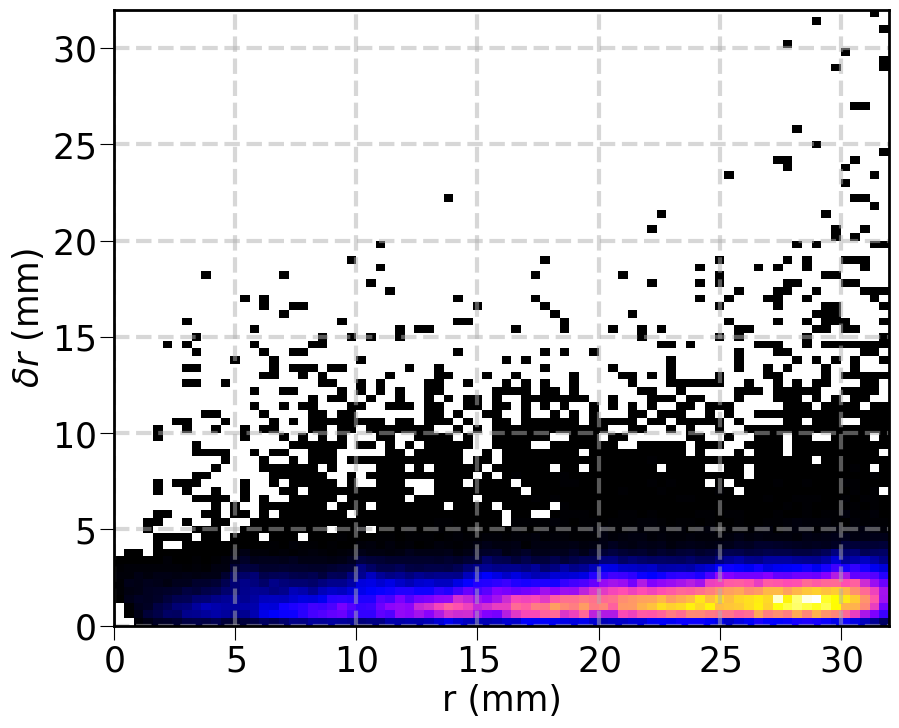

In [38]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

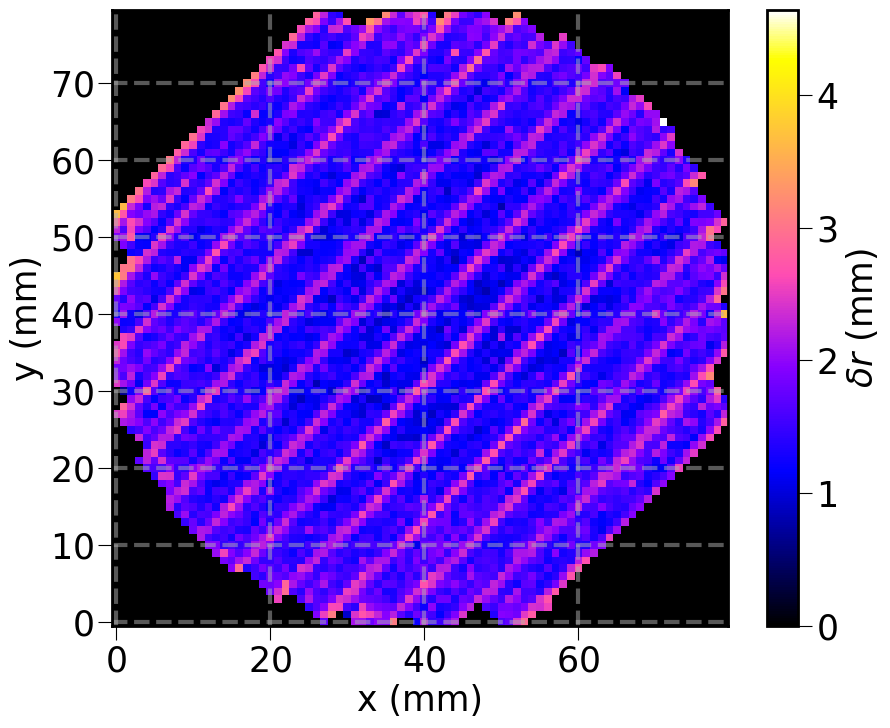

In [51]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=3*np.median(errs[errs>0]))
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

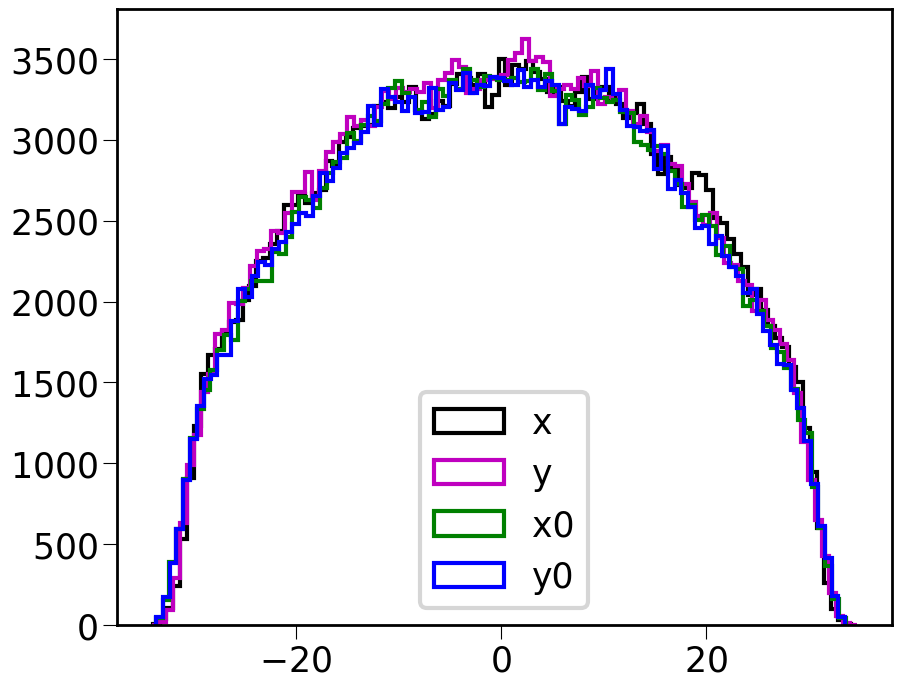

In [30]:
plt.hist(reco_nn.x , 101, histtype="step", label="x");
plt.hist(reco_nn.y , 101, histtype="step", label="y");
plt.hist(reco_nn.x0, 101, histtype="step", label="x0");
plt.hist(reco_nn.y0, 101, histtype="step", label="y0");
plt.legend()

In [31]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,9.575744,-9.123943,13.226535,8.441956,-6.907363,-1.133788,2.216580,2.489719
1,-0.019997,-13.793411,13.793425,-2.043210,-12.690548,-2.023213,1.102863,2.304278
2,11.848175,25.898636,28.480144,14.225309,24.434153,2.377134,-1.464483,2.792038
3,6.791997,-18.881091,20.065563,9.074098,-18.586533,2.282101,0.294557,2.301032
4,11.075792,0.122486,11.076469,12.207673,0.919820,1.131881,0.797334,1.384520
...,...,...,...,...,...,...,...,...
49995,-0.428772,25.278715,25.282351,-1.256023,25.007938,-0.827251,-0.270777,0.870440
49996,-10.653825,8.629949,13.710580,-9.669960,7.829479,0.983865,-0.800469,1.268362
49997,24.257606,17.487896,29.904146,21.520312,18.513886,-2.737294,1.025989,2.923257


In [32]:
reco = pd.DataFrame.join( reco_bb
                        , reco_nn.drop(columns="x0 y0 r0".split())
                        , lsuffix="_bb"
                        , rsuffix="_nn")

In [33]:
reco

,x_bb,y_bb,x0,y0,z0,r0,dx_bb,dy_bb,dr_bb,x_nn,y_nn,dx_nn,dy_nn,dr_nn
event,,,,,,,,,,,,,,
0,-10.613194,17.459028,-15.999181,25.851183,-5.193165,30.401603,5.385987,-8.392156,9.971817,8.441956,-6.907363,-1.133788,2.216580,2.489719
0,-10.613194,17.459028,-15.999181,25.851183,-5.193165,30.401603,5.385987,-8.392156,9.971817,16.659918,8.490750,2.420873,-0.644574,2.505215
0,-10.613194,17.459028,-15.999181,25.851183,-5.193165,30.401603,5.385987,-8.392156,9.971817,9.204526,24.768259,-1.494886,-0.323319,1.529451
0,-10.613194,17.459028,-15.999181,25.851183,-5.193165,30.401603,5.385987,-8.392156,9.971817,-4.766045,17.406021,-0.052067,-0.191953,0.198889
0,-10.613194,17.459028,-15.999181,25.851183,-5.193165,30.401603,5.385987,-8.392156,9.971817,-17.586657,-7.266257,0.365010,1.911976,1.946506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49999,13.316119,-9.133433,17.615601,-12.598593,-5.179261,21.657191,-4.299481,3.465160,5.522035,-25.923521,-8.663284,1.836629,-1.318681,2.261001
49999,13.316119,-9.133433,17.615601,-12.598593,-5.179261,21.657191,-4.299481,3.465160,5.522035,1.345660,-31.463169,1.419054,-1.337978,1.950359
49999,13.316119,-9.133433,17.615601,-12.598593,-5.179261,21.657191,-4.299481,3.465160,5.522035,-18.209626,19.503607,1.784005,-1.923332,2.623334


In [34]:
reco.to_hdf(output, key="/data", complib="zlib", complevel=4)

NameError: name 'output' is not defined

In [ ]:
normhist(reco.x0  , 101, histtype="step", label="x$_{true}$");
normhist(reco.y0  , 101, histtype="step", label="y$_{true}$");
normhist(reco.x_bb, 101, histtype="step", label="x$_{B}$");
normhist(reco.y_bb, 101, histtype="step", label="y$_{B}$");
normhist(reco.x_nn, 101, histtype="step", label="x$_{NN}$");
normhist(reco.y_nn, 101, histtype="step", label="y$_{NN}$");
plt.legend()
plt.xlabel("x,y (mm)")
plt.ylabel("Frequency (%)")
plt.grid()